# NOTEBOOK B
___
* UNSUPERVISED LEARNING - CLUSTERING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score
from collections import Counter

from mpl_toolkits.mplot3d import Axes3D
# pip install ipympl (One-time installation this if you want 3D plot rotation)
# %matplotlib widget (Optional - Always run this if you want interactive)

from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

import umap # pip install umap-learn
from sklearn.manifold import TSNE

In [ ]:
# DATASET LOAD & OVERVIEW
path = 'SRTEMPLOYEES2026A.csv'
df = pd.read_csv(path)
print(df.info())
print(df.isnull().sum())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 19026 entries, 0 to 19025
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          19026 non-null  str    
 1   LEVEL       19026 non-null  int64  
 2   TYPE        19026 non-null  str    
 3   DEPARTMENT  19026 non-null  str    
 4   DOB         19026 non-null  str    
 5   AGE         19026 non-null  int64  
 6   COURSE      15862 non-null  str    
 7   PILLAR      15862 non-null  float64
 8   GENERAL     19026 non-null  int64  
 9   TECHNICAL   19026 non-null  int64  
 10  DIGITAL     19026 non-null  int64  
dtypes: float64(1), int64(5), str(5)
memory usage: 1.6 MB
None
ID               0
LEVEL            0
TYPE             0
DEPARTMENT       0
DOB              0
AGE              0
COURSE        3164
PILLAR        3164
GENERAL          0
TECHNICAL        0
DIGITAL          0
dtype: int64


,ID,LEVEL,TYPE,DEPARTMENT,DOB,AGE,COURSE,PILLAR,GENERAL,TECHNICAL,DIGITAL
0,SRT_1,14,Governance & Support,Governor Bureau,8/9/1971,54,โครงการพัฒนาผู้บริหารระดับสูง (Crucial Convers...,1.0,1,0,0
1,SRT_2,14,Governance & Support,Governor Bureau,11/10/1965,60,การบริหารความต่อเนื่องทางธุรกิจระดับองค์กร,1.0,1,0,0
2,SRT_3,14,Governance & Support,Governor Bureau,18/8/1970,55,NaN,NaN,0,0,0
3,SRT_4,14,Governance & Support,Governor Bureau,2/7/1967,58,NaN,NaN,0,0,0
4,SRT_5,14,Governance & Support,Governor Bureau,19/6/1969,56,NaN,NaN,0,0,0


In [3]:
# FILL MISSING VALUES FOR THOSE EMPLOYEES WITHOUT TRAINING
df['COURSE'] = df['COURSE'].fillna('N/A')
df['PILLAR'] = df['PILLAR'].fillna(0).astype(int)
df[['COURSE', 'PILLAR']].isna().sum()

COURSE    0
PILLAR    0
dtype: int64

In [4]:
df.head()

,ID,LEVEL,TYPE,DEPARTMENT,DOB,AGE,COURSE,PILLAR,GENERAL,TECHNICAL,DIGITAL
0,SRT_1,14,Governance & Support,Governor Bureau,8/9/1971,54,โครงการพัฒนาผู้บริหารระดับสูง (Crucial Convers...,1,1,0,0
1,SRT_2,14,Governance & Support,Governor Bureau,11/10/1965,60,การบริหารความต่อเนื่องทางธุรกิจระดับองค์กร,1,1,0,0
2,SRT_3,14,Governance & Support,Governor Bureau,18/8/1970,55,N/A,0,0,0,0
3,SRT_4,14,Governance & Support,Governor Bureau,2/7/1967,58,N/A,0,0,0,0
4,SRT_5,14,Governance & Support,Governor Bureau,19/6/1969,56,N/A,0,0,0,0


In [5]:
# UNIQUE TYPE IN SERVICES
df['TYPE'].unique()

<StringArray>
[            'Governance & Support',                       'Operations',
   'Infrastructure & Rolling Stock', 'Strategic Business & Real Estate']
Length: 4, dtype: str

In [6]:
# CREATE A SEPARATE DATAFRAME TO DISPLAY THE TOTAL TRAINING RECEIVED
dftr = (
    df[df['COURSE'] != 'N/A'].groupby('ID', sort=False).size().reindex(df['ID'].unique(), fill_value=0).reset_index(name='TOTALTRAINING')
)
dftr.head()

,ID,TOTALTRAINING
0,SRT_1,1
1,SRT_2,1
2,SRT_3,0
3,SRT_4,0
4,SRT_5,0


___
#### UNSUPERVISED LEARNING - CLUSTERING
STATIC SEGMENTATION

Features to use:
* LEVEL → hierarchical / seniority signal
* GENERAL, TECHNICAL, DIGITAL, RECEIVED → training exposure (capability proxy)
* TYPE (3 one-hot columns) → functional domain

Identify workforce segments: “seniority × capability × functional domain (organisational function)”

*Possible segments*

A. Capability-based segments

Driven by: GENERAL / TECHNICAL / DIGITAL
* Likely clusters:
    * Low training exposure - Few courses across all categories
    * Technically specialised - High TECHNICAL, low GENERAL/DIGITAL
    * Digitally enabled workforce - High DIGITAL
    * Well-rounded / highly trained - High across all three

B. Organisational role segments

Driven by: TYPE (one-hot encoded)
* Likely clusters:
    * Governance-heavy cluster
    * Infrastructure-heavy cluster
    * Operations-heavy cluster

C. Seniority-driven segments
Driven by: LEVEL
* Likely clusters:
    * Junior workforce
    * Mid-level workforce
    * Senior / leadership cohort


*Combined workforce segments (more realistic outcomes)*

1. Senior but under-trained - High LEVEL - Low training counts → Risk: leadership capability gap

2. Junior but highly trained (high-potential) - Low LEVEL - High DIGITAL / TECHNICAL

3. Operationally specialised technicians - TYPE: Operations - High TECHNICAL - Moderate LEVEL → Core execution workforce

4. Digitally progressive governance staff - TYPE: Governance - High DIGITAL → Transformation drivers

5. Low-engagement workforce - Low across all training variables → Training penetration issue

In [7]:
# VALUE COUNTS ON THE CATEGORICAL FIELDS
print(f'{df['TYPE'].value_counts()}\n')
print(f'{df['DEPARTMENT'].value_counts()}\n')
print(f'{df['LEVEL'].value_counts()}')

TYPE
Infrastructure & Rolling Stock      9320
Operations                          5632
Governance & Support                3506
Strategic Business & Real Estate     568
Name: count, dtype: int64

DEPARTMENT
Machanical Engineering Department                            4918
Civil Engineering Department                                 3272
Traffic Operation Department                                 3249
Passenger Service Department                                 1399
Freight Service Department                                    984
Signalling and Telecommunications Department                  815
Human Resource Department                                     441
Internal Auditing Department                                  384
Institute of Railway Training                                 367
Stores Department                                             334
Information Technology Department                             300
Procurement Bureau (Rollingstock Stock Management)            266
F

In [ ]:
# MULTISTEP PREP 1: DATASET COPY + DROP COLUMNS + GROUPBY-AGG + SUM-NEW COLUMN
data = df.copy()
data['DOB'] = pd.to_datetime(data['DOB'], format='%d/%m/%Y', errors='coerce')
data.drop(['DEPARTMENT', 'COURSE', 'PILLAR'], axis=1, inplace=True)
data = (
    data.groupby('ID', sort=False, as_index=False)
        .agg({
            'LEVEL': 'first',
            'TYPE': 'first',
            'GENERAL': 'sum',
            'TECHNICAL': 'sum',
            'DIGITAL': 'sum'
        })
)
data['TOTALTRAINING'] = data[['GENERAL', 'TECHNICAL', 'DIGITAL']].sum(axis=1)
data

,ID,LEVEL,TYPE,GENERAL,TECHNICAL,DIGITAL,TOTALTRAINING
0,SRT_1,14,Governance & Support,1,0,0,1
1,SRT_2,14,Governance & Support,1,0,0,1
2,SRT_3,14,Governance & Support,0,0,0,0
3,SRT_4,14,Governance & Support,0,0,0,0
4,SRT_5,14,Governance & Support,0,0,0,0
...,...,...,...,...,...,...,...
8268,SRT_8269,8,Governance & Support,5,0,0,5
8269,SRT_8270,8,Governance & Support,3,1,0,4
8270,SRT_8271,8,Governance & Support,12,2,1,15
8271,SRT_8272,6,Governance & Support,3,2,3,8


In [ ]:
# MULTISTEP PREP 2: DATASET COPY + ONE-HOT ENCODING + CONCATENATE DATAFRAME + DROP COLUMN
t = pd.get_dummies(data['TYPE']).astype('int')
data = pd.concat([data, t], axis=1)
datamo = data.drop(['ID', 'TYPE'], axis=1)
print(f'NUMBER OF DATA ROWS: {datamo.shape[0]}')
print(f'NUMBER OF DATA COLUMNS:{datamo.shape[1]}')
datamo.head()

NUMBER OF DATA ROWS: 8273
NUMBER OF DATA COLUMNS:9


,LEVEL,GENERAL,TECHNICAL,DIGITAL,TOTALTRAINING,Governance & Support,Infrastructure & Rolling Stock,Operations,Strategic Business & Real Estate
0,14,1,0,0,1,1,0,0,0
1,14,1,0,0,1,1,0,0,0
2,14,0,0,0,0,1,0,0,0
3,14,0,0,0,0,1,0,0,0
4,14,0,0,0,0,1,0,0,0


In [ ]:
# EDA: AVERAGE NUMBER OF TRAINING COURSES RECEIVED BY EMPLOYEES LEVEL(RANK)
e1 = datamo.drop(['Governance & Support', 'Infrastructure & Rolling Stock', 'Operations', 'Strategic Business & Real Estate'], axis=1)
e1.groupby('LEVEL').mean().round(2)

,GENERAL,TECHNICAL,DIGITAL,TOTALTRAINING
LEVEL,,,,
1,0.08,0.58,0.00,0.65
2,0.12,0.68,0.01,0.82
3,0.10,0.74,0.02,0.86
4,0.16,0.89,0.04,1.10
5,0.12,0.98,0.04,1.14
6,0.47,1.27,0.21,1.95
7,0.21,2.00,0.11,2.32
8,2.86,1.68,0.66,5.20
10,4.37,2.38,0.60,7.36


In [11]:
# DATAPREP: SCALING/STANDARISATION
scaler = StandardScaler()
scdata = scaler.fit_transform(datamo)
dfs = pd.DataFrame(scdata, columns=datamo.columns)
dfs.head().round(3)

,LEVEL,GENERAL,TECHNICAL,DIGITAL,TOTALTRAINING,Governance & Support,Infrastructure & Rolling Stock,Operations,Strategic Business & Real Estate
0,4.616,0.224,-0.672,-0.248,-0.301,3.645,-1.068,-0.798,-0.089
1,4.616,0.224,-0.672,-0.248,-0.301,3.645,-1.068,-0.798,-0.089
2,4.616,-0.316,-0.672,-0.248,-0.628,3.645,-1.068,-0.798,-0.089
3,4.616,-0.316,-0.672,-0.248,-0.628,3.645,-1.068,-0.798,-0.089
4,4.616,-0.316,-0.672,-0.248,-0.628,3.645,-1.068,-0.798,-0.089


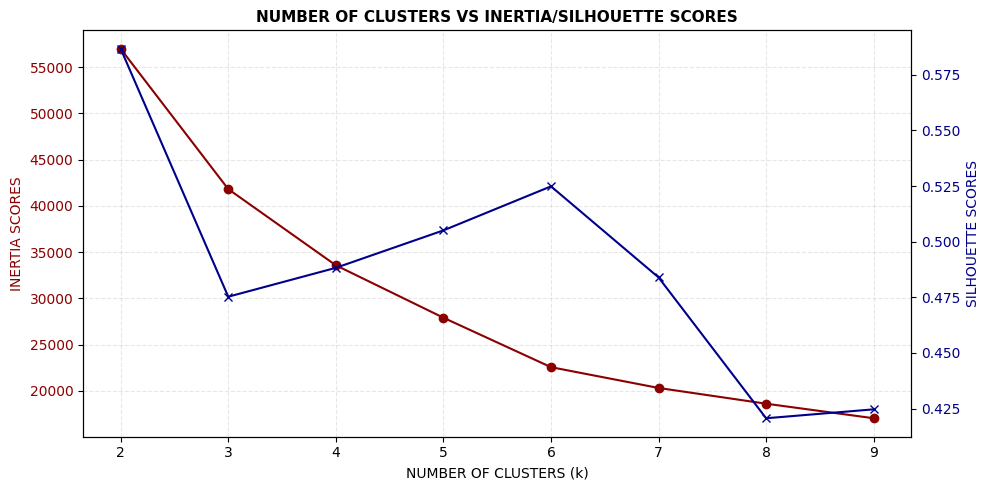

In [ ]:
# K-MEANS CLUSTERING: OPTIMAL CLUSTERS NUMBER SEARCH (ELBOW METHOD)
iv = []
ss = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, n_init=10, random_state=1234).fit(dfs)
    iv.append(km.inertia_)
    sss = silhouette_score(dfs, km.labels_, metric='euclidean', sample_size=None)
    ss.append(sss)

i = pd.Series(iv, index=range(2, 10))
s = pd.Series(ss, index=range(2, 10))

fig, ax0 = plt.subplots(figsize=(10, 5))
ax0.plot(i, marker='o', color='darkred', label='INERTIA SCORES')
ax0.set_ylabel('INERTIA SCORES', color='darkred')
ax0.tick_params(axis='y', labelcolor='darkred')

ax1 = ax0.twinx()
ax1.plot(s, marker='x', color='darkblue', label='SILHOUETTE SCORES')
ax1.set_ylabel('SILHOUETTE SCORES', color='darkblue')
ax1.tick_params(axis='y', labelcolor='darkblue')

ax0.grid(True, linestyle='--', alpha=0.3)
ax0.set_xlabel('NUMBER OF CLUSTERS (k)')
plt.title('NUMBER OF CLUSTERS VS INERTIA/SILHOUETTE SCORES', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show();

CLUSTER LABEL COUNT:Counter({np.int32(3): 3856, np.int32(0): 3127, np.int32(1): 560, np.int32(5): 428, np.int32(2): 237, np.int32(4): 65})



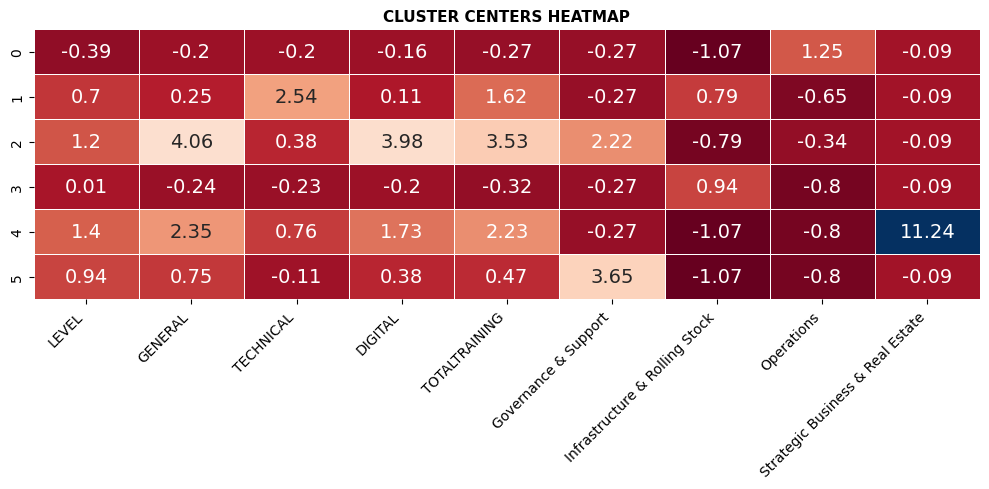

In [ ]:
# MODEL REFIT + LABEL COUNT + CLUSTER CENTRES HEATMAP
km6 = KMeans(n_clusters=6, n_init=10, random_state=1234).fit(dfs)
print(f'CLUSTER LABEL COUNT:{Counter(km6.labels_)}\n')

plt.figure(figsize=(10, 5))
cc6 = pd.DataFrame(np.round(km6.cluster_centers_, 2), columns=dfs.columns)
sns.heatmap(cc6, annot=True, cmap='RdBu', fmt='g', linewidths=0.5, annot_kws={'size': 14}, cbar=False)
plt.title('CLUSTER CENTERS HEATMAP', fontsize=11, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('F3.png', dpi=600, bbox_inches='tight')
plt.show();
#INTERPRETATION:
# CLUSTER 0: Core Frontline Operations Staff
# CLUSTER 1: Specialized Technical Field Experts
# CLUSTER 2: Advanced Governance & Support Specialists
# CLUSTER 3: Essential Infrastructure Field Crew
# CLUSTER 4: Strategic Business & Real Estate Leaders
# CLUSTER 5: Governance & Support Professionals

In [ ]:
# PRINCIPAL COMPONENT ANALYSIS (PCA) - DIMENSIONALITY REDUCTION
pca2 = PCA(n_components=2).fit(dfs)
print(f'EXPLAINED VARIANCE RATIO: {np.cumsum(pca2.explained_variance_ratio_.round(3))}\n')
print(dfs.columns)

EXPLAINED VARIANCE RATIO: [0.343 0.56 ]

Index(['LEVEL', 'GENERAL', 'TECHNICAL', 'DIGITAL', 'TOTALTRAINING',
       'Governance & Support', 'Infrastructure & Rolling Stock', 'Operations',
       'Strategic Business & Real Estate'],
      dtype='str')


In [19]:
# TRANSFORM THE SCALED DATA INTO TWO AXES
dfst2 = pd.DataFrame(pca2.transform(dfs), columns=['PC1', 'PC2'])
dfst2.head()

,PC1,PC2
0,2.475213,0.043743
1,2.475213,0.043743
2,2.043157,0.111689
3,2.043157,0.111689
4,2.043157,0.111689


In [ ]:
# INSPECT PCA2 LOADINGS
loadings = pd.DataFrame(
    pca2.components_,
    columns=datamo.columns,
    index=['PC1', 'PC2']
)
print(loadings.T.sort_values('PC1', ascending=False))
print(loadings.T.sort_values('PC2', ascending=False))

                                       PC1       PC2
TOTALTRAINING                     0.527542 -0.009337
GENERAL                           0.480477 -0.120290
DIGITAL                           0.405899 -0.132527
Governance & Support              0.332923 -0.127427
LEVEL                             0.309596  0.181427
TECHNICAL                         0.260982  0.161355
Strategic Business & Real Estate  0.158636 -0.032904
Infrastructure & Rolling Stock   -0.047261  0.695331
Operations                       -0.154560 -0.638845
                                       PC1       PC2
Infrastructure & Rolling Stock   -0.047261  0.695331
LEVEL                             0.309596  0.181427
TECHNICAL                         0.260982  0.161355
TOTALTRAINING                     0.527542 -0.009337
Strategic Business & Real Estate  0.158636 -0.032904
GENERAL                           0.480477 -0.120290
Governance & Support              0.332923 -0.127427
DIGITAL                           0.405899 -0.

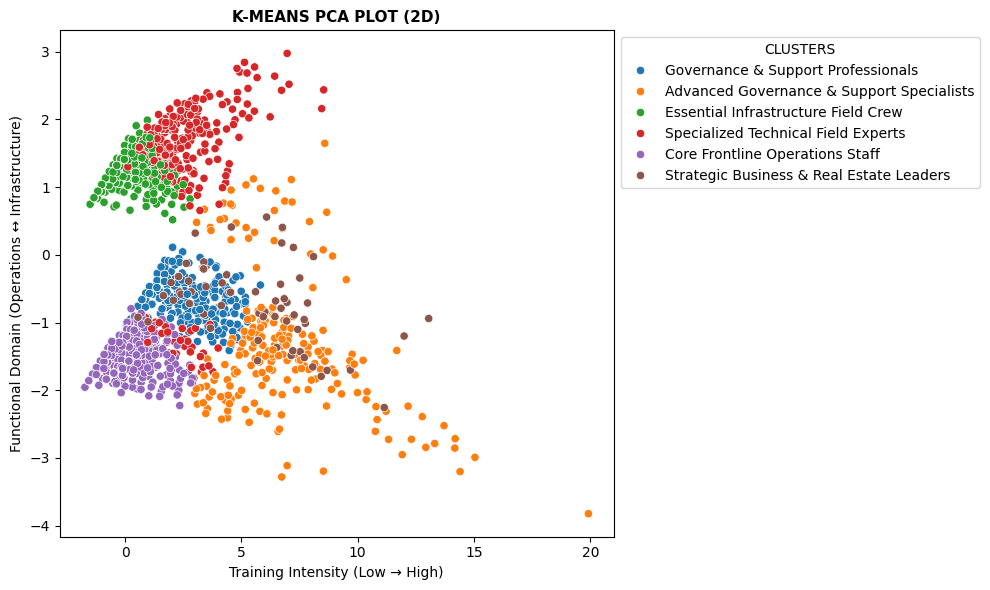

In [21]:
# SCATTER PLOT WITH COLOUR OVERLAY FOR 6 CLUSTERS
clabels = {
    0: 'Core Frontline Operations Staff',
    1: 'Specialized Technical Field Experts',
    2: 'Advanced Governance & Support Specialists',
    3: 'Essential Infrastructure Field Crew',
    4: 'Strategic Business & Real Estate Leaders',
    5: 'Governance & Support Professionals'
}
dfst2['CLUSTER'] = km6.labels_
dfst2['CLABEL'] = dfst2['CLUSTER'].map(clabels)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=dfst2, x='PC1', y='PC2', hue='CLABEL', palette='tab10')
plt.title('K-MEANS PCA PLOT (2D)', fontsize=11, fontweight='bold')
plt.xlabel('Training Intensity (Low → High)')
plt.ylabel('Functional Domain (Operations ↔ Infrastructure)')
plt.legend(title='CLUSTERS', bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.savefig('F4.png', dpi=600, bbox_inches='tight')
plt.show();

In [ ]:
# PRINCIPAL COMPONENT ANALYSIS (PCA) - DIMENSIONALITY REDUCTION
pca3 = PCA(n_components=3).fit(dfs)
print(f'EXPLAINED VARIANCE RATIO: {np.cumsum(pca3.explained_variance_ratio_.round(3))}\n')
print(dfs.columns)

EXPLAINED VARIANCE RATIO: [0.343 0.56  0.691]

Index(['LEVEL', 'GENERAL', 'TECHNICAL', 'DIGITAL', 'TOTALTRAINING',
       'Governance & Support', 'Infrastructure & Rolling Stock', 'Operations',
       'Strategic Business & Real Estate'],
      dtype='str')


In [23]:
# TRANSFORM THE SCALED DATA INTO THREE AXES
dfst3 = pd.DataFrame(pca3.transform(dfs), columns=['PC1', 'PC2', 'PC3'])
dfst3.head()

,PC1,PC2,PC3
0,2.475213,0.043743,-3.432571
1,2.475213,0.043743,-3.432571
2,2.043157,0.111689,-3.457871
3,2.043157,0.111689,-3.457871
4,2.043157,0.111689,-3.457871


In [24]:
# INSPECT PCA3 LOADINGS
loadings = pd.DataFrame(
    pca3.components_,
    columns=datamo.columns,
    index=['PC1', 'PC2', 'PC3']
)
print(loadings.T.sort_values('PC1', ascending=False))
print(loadings.T.sort_values('PC2', ascending=False))
print(loadings.T.sort_values('PC3', ascending=False))
# PC1: Training Intensity / Capability Development (Low → High)
# PC2: Functional domain (Operations ↔ Infrastructure)
# PC3: Role Specialization (Governance ↔ Technical)

                                       PC1       PC2       PC3
TOTALTRAINING                     0.527542 -0.009337  0.291312
GENERAL                           0.480477 -0.120290 -0.130074
DIGITAL                           0.405899 -0.132527 -0.098052
Governance & Support              0.332923 -0.127427 -0.532355
LEVEL                             0.309596  0.181427 -0.158402
TECHNICAL                         0.260982  0.161355  0.685800
Strategic Business & Real Estate  0.158636 -0.032904  0.215634
Infrastructure & Rolling Stock   -0.047261  0.695331 -0.011549
Operations                       -0.154560 -0.638845  0.251313
                                       PC1       PC2       PC3
Infrastructure & Rolling Stock   -0.047261  0.695331 -0.011549
LEVEL                             0.309596  0.181427 -0.158402
TECHNICAL                         0.260982  0.161355  0.685800
TOTALTRAINING                     0.527542 -0.009337  0.291312
Strategic Business & Real Estate  0.158636 -0.032904  0

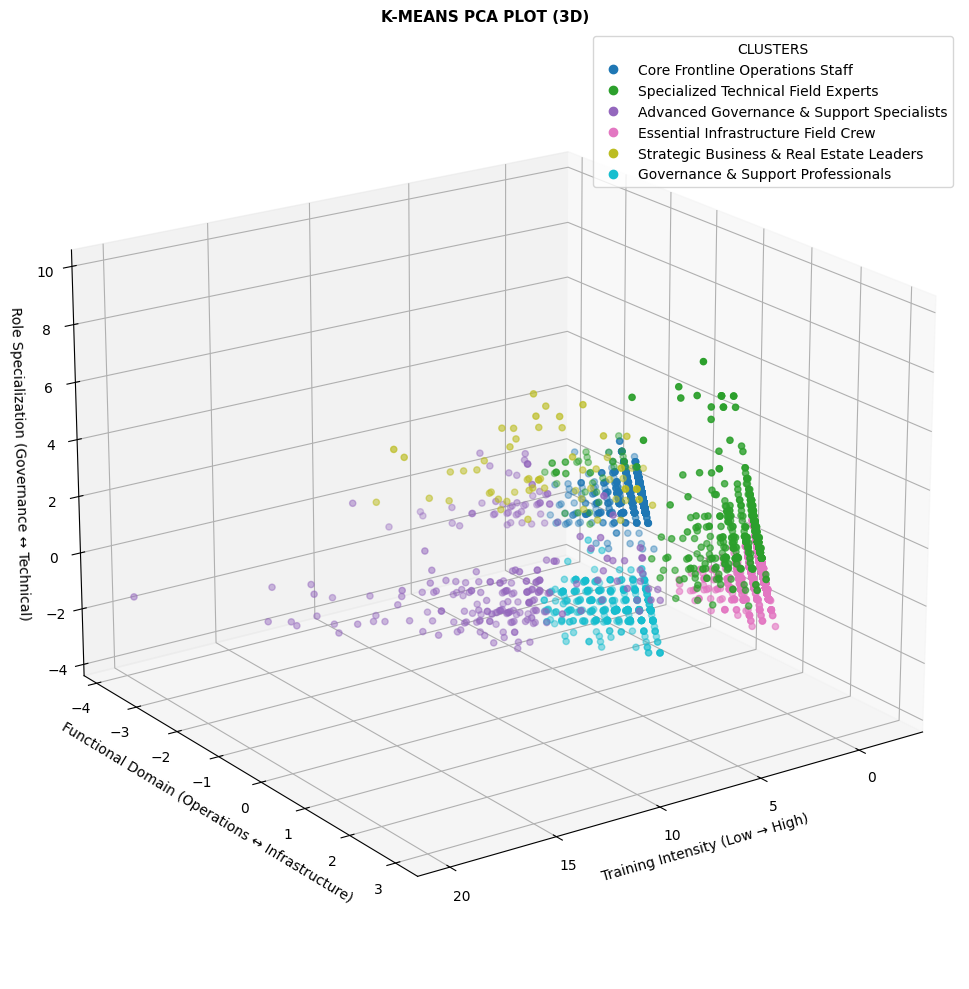

In [25]:
# 3D MODEL VISUALISATION (BASED ON THE K-MEANS 6 CLUSTERS MODEL - km6)
clabels = {
    0: 'Core Frontline Operations Staff',
    1: 'Specialized Technical Field Experts',
    2: 'Advanced Governance & Support Specialists',
    3: 'Essential Infrastructure Field Crew',
    4: 'Strategic Business & Real Estate Leaders',
    5: 'Governance & Support Professionals'
}
dfst3['CLUSTER'] = km6.labels_
dfst3['CLABEL'] = dfst3['CLUSTER'].map(clabels)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')
sc = ax.scatter(xs=dfst3['PC1'], ys=dfst3['PC2'], zs=dfst3['PC3'], c=dfst3['CLUSTER'], cmap='tab10')

ax.set_title('K-MEANS PCA PLOT (3D)', fontsize=11, fontweight='bold')
ax.set_xlabel('Training Intensity (Low → High)')
ax.set_ylabel('Functional Domain (Operations ↔ Infrastructure)')
ax.set_zlabel('Role Specialization (Governance ↔ Technical)')

ax.view_init(elev=20, azim=55)
handles, _ = sc.legend_elements()
legend_labels = [clabels[i] for i in range(len(handles))]
ax.legend(handles, legend_labels, title='CLUSTERS', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show();

___
UMAP & t-SNE

In [26]:
# FIT UMAP TWO COMPONENTS (BASED ON THE SAME FEATURES AS PCA)
umap2 = umap.UMAP(n_components=2, n_neighbors=25, min_dist=0.2, metric='euclidean').fit_transform(dfs)
dfumap2 = pd.DataFrame(umap2, columns=['UMAP1', 'UMAP2'])
dfumap2['CLUSTER'] = km6.labels_
dfumap2['CLABEL'] = dfumap2['CLUSTER'].map(clabels)
dfumap2.head()

,UMAP1,UMAP2,CLUSTER,CLABEL
0,-0.160774,-0.365598,5,Governance & Support Professionals
1,-0.174077,-0.376218,5,Governance & Support Professionals
2,-0.177008,-0.363817,5,Governance & Support Professionals
3,-0.184279,-0.360852,5,Governance & Support Professionals
4,-0.202616,-0.340167,5,Governance & Support Professionals


NOTES - PARAMETER TUNING IN UMAP (SENSITIVE TO PARAMETERS)
1. n_neighbors (STRUCTURE SCALE)
    * 5–10 → LOCAL (TIGHT CLUSTERS)
    * 15–30 → BALANCED
    * 50+ → GLOBAL
2. min_dist (CLUSTER COMPACTNESS)
    * 0.0–0.1 → TIGHT
    * 0.3–0.5 → SPREAD OUT

* TRIAL AND ERROR TO ACHIEVE DISTINCT, SEPARATED CLUSTER 'ISLANDS
* TRY TO TO ACHIEVE MINIMAL OVERLAP BETWEEN CLUSTERS

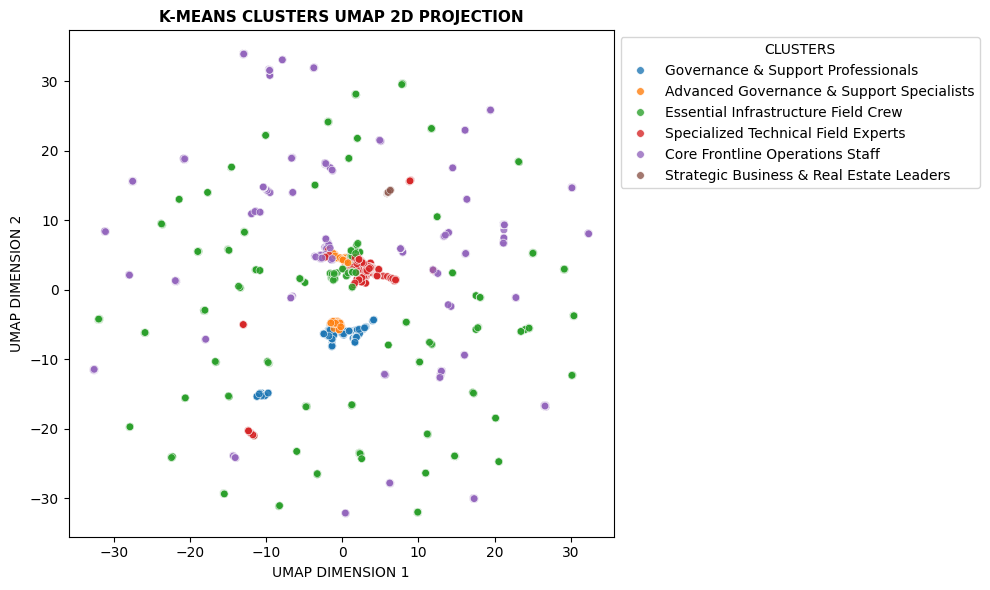

In [ ]:
# UMAP TWO COMPONENTS 2D SCATTER PLOT
# Note: Axes have no meaning!
plt.figure(figsize=(10, 6))
sns.scatterplot(data=dfumap2, x='UMAP1', y='UMAP2', hue='CLABEL', palette='tab10', s=30, alpha=0.8)
plt.title('K-MEANS CLUSTERS UMAP 2D PROJECTION', fontsize=11, fontweight='bold')
plt.xlabel('UMAP DIMENSION 1')
plt.ylabel('UMAP DIMENSION 2')
plt.legend(title='CLUSTERS', bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show();

In [29]:
# FIT UMAP THREE COMPONENTS (BASED ON THE SAME FEATURES AS PCA)
umap3 = umap.UMAP(n_components=3, n_neighbors=30, min_dist=0.1, metric='euclidean').fit_transform(dfs)
dfumap3 = pd.DataFrame(umap3, columns=['UMAP1', 'UMAP2', 'UMAP3'])
dfumap3['CLUSTER'] = km6.labels_
dfumap3['CLABEL'] = dfumap3['CLUSTER'].map(clabels)
dfumap3.head()

,UMAP1,UMAP2,UMAP3,CLUSTER,CLABEL
0,-2.782056,2.354042,1.264516,5,Governance & Support Professionals
1,-2.779535,2.350989,1.266784,5,Governance & Support Professionals
2,-2.782872,2.355709,1.262674,5,Governance & Support Professionals
3,-2.771408,2.344444,1.266770,5,Governance & Support Professionals
4,-2.781595,2.354696,1.262915,5,Governance & Support Professionals


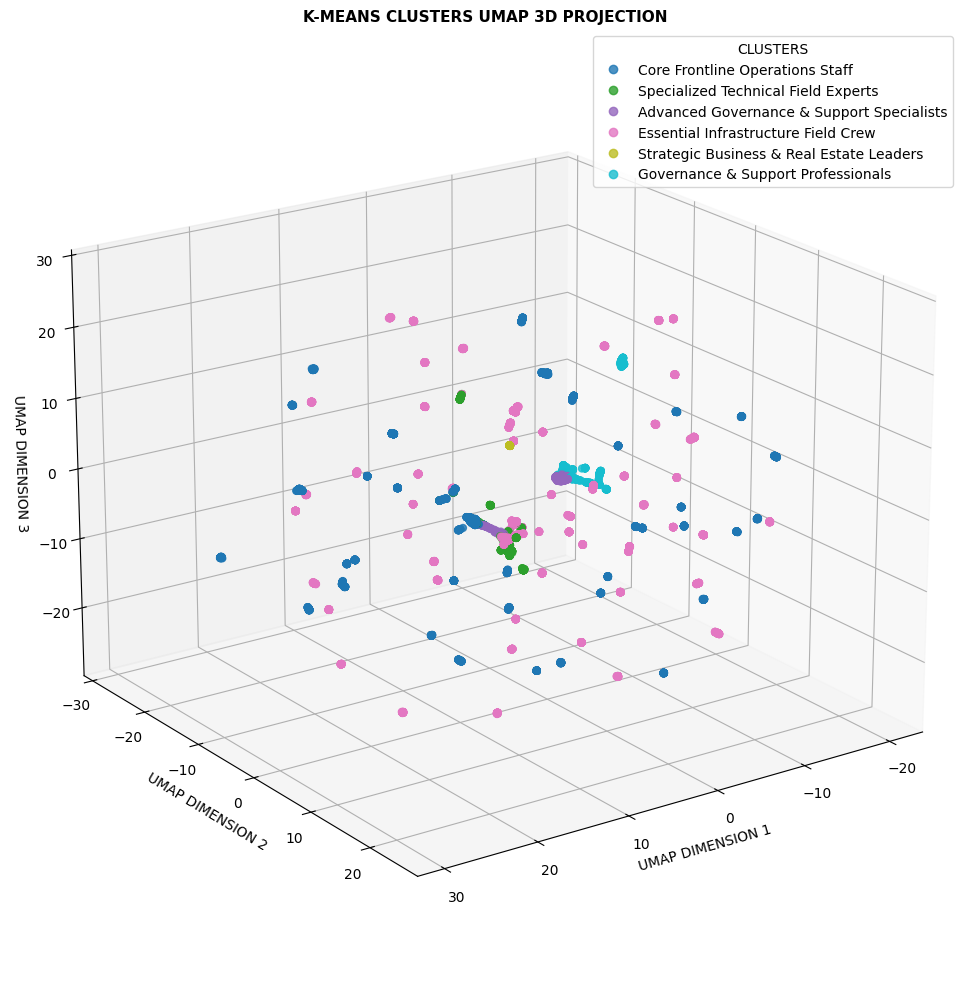

In [ ]:
# UMAP THREE COMPONENTS 3D SCATTER PLOT
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')
sc = ax.scatter(xs=dfumap3['UMAP1'], ys=dfumap3['UMAP2'], zs=dfumap3['UMAP3'], c=dfumap3['CLUSTER'], cmap='tab10', s=25, alpha=0.8)
ax.set_title('K-MEANS CLUSTERS UMAP 3D PROJECTION', fontsize=11, fontweight='bold')
ax.set_xlabel('UMAP DIMENSION 1')
ax.set_ylabel('UMAP DIMENSION 2')
ax.set_zlabel('UMAP DIMENSION 3')
ax.view_init(elev=20, azim=55)
handles, _ = sc.legend_elements()
legend_labels = [clabels[i] for i in range(len(handles))]
ax.legend(handles, legend_labels, title='CLUSTERS', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show();

In [31]:
# FIT t-SNE TWO COMPONENTS (BASED ON THE SAME FEATURES AS PCA)
tsne2 = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca').fit_transform(dfs)
dftsne2 = pd.DataFrame(tsne2, columns=['TSNE1', 'TSNE2'])
dftsne2['CLUSTER'] = km6.labels_
dftsne2['CLABEL'] = dftsne2['CLUSTER'].map(clabels)
dftsne2.head()

,TSNE1,TSNE2,CLUSTER,CLABEL
0,73.643539,-0.820835,5,Governance & Support Professionals
1,73.643539,-0.820835,5,Governance & Support Professionals
2,73.874359,-0.173538,5,Governance & Support Professionals
3,73.874359,-0.173538,5,Governance & Support Professionals
4,73.874359,-0.173538,5,Governance & Support Professionals


NOTES - t-SNE KEY PARAMETERS
1. perplexity:
    * ~5–10 → LOCAL STRUCTURE
    * ~30 (default) → BALANCED
    * ~50+ → GLOBAL
2. init='pca':
    * STABILISES RESULTS

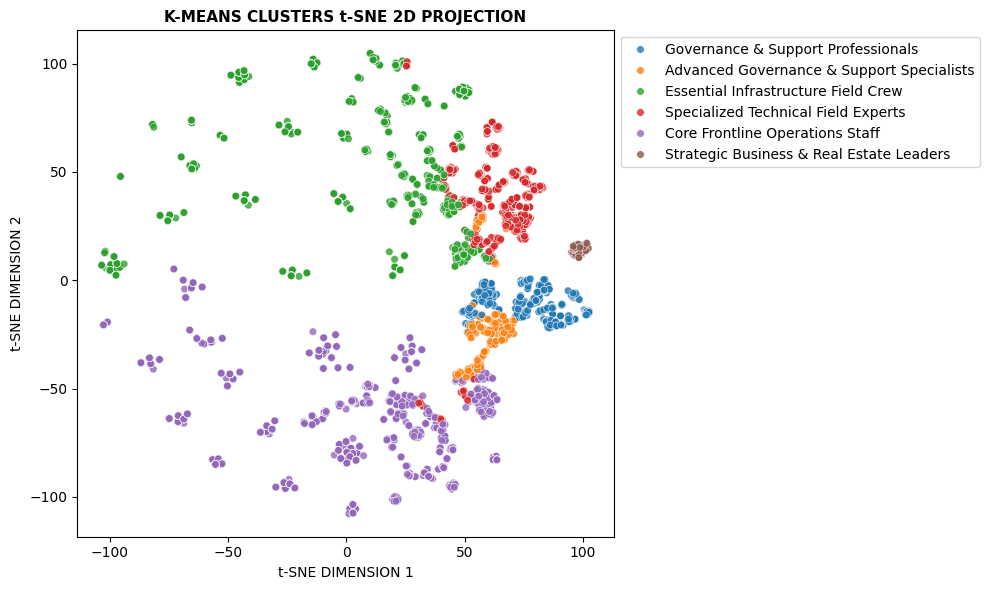

In [ ]:
# t-SNE TWO COMPONENTS 2D SCATTER PLOT
plt.figure(figsize=(10, 6))
sns.scatterplot(data=dftsne2, x='TSNE1', y='TSNE2', hue='CLABEL', palette='tab10', s=30,  alpha=0.8)
plt.title('K-MEANS CLUSTERS t-SNE 2D PROJECTION', fontsize=11, fontweight='bold')
plt.xlabel('t-SNE DIMENSION 1')
plt.ylabel('t-SNE DIMENSION 2')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show();

In [33]:
# FIT t-SNE THREE COMPONENTS (BASED ON THE SAME FEATURES AS PCA)
tsne3 = TSNE(n_components=3, perplexity=30, learning_rate='auto', init='pca').fit_transform(dfs)
dftsne3 = pd.DataFrame(tsne3, columns=['TSNE1', 'TSNE2', 'TSNE3'])
dftsne3['CLUSTER'] = km6.labels_
dftsne3['CLABEL'] = dftsne3['CLUSTER'].map(clabels)
dftsne3.head()

,TSNE1,TSNE2,TSNE3,CLUSTER,CLABEL
0,22.047535,3.317593,-17.249636,5,Governance & Support Professionals
1,22.047535,3.317593,-17.249636,5,Governance & Support Professionals
2,22.099609,3.723028,-18.012480,5,Governance & Support Professionals
3,22.099609,3.723028,-18.012480,5,Governance & Support Professionals
4,22.099609,3.723028,-18.012480,5,Governance & Support Professionals


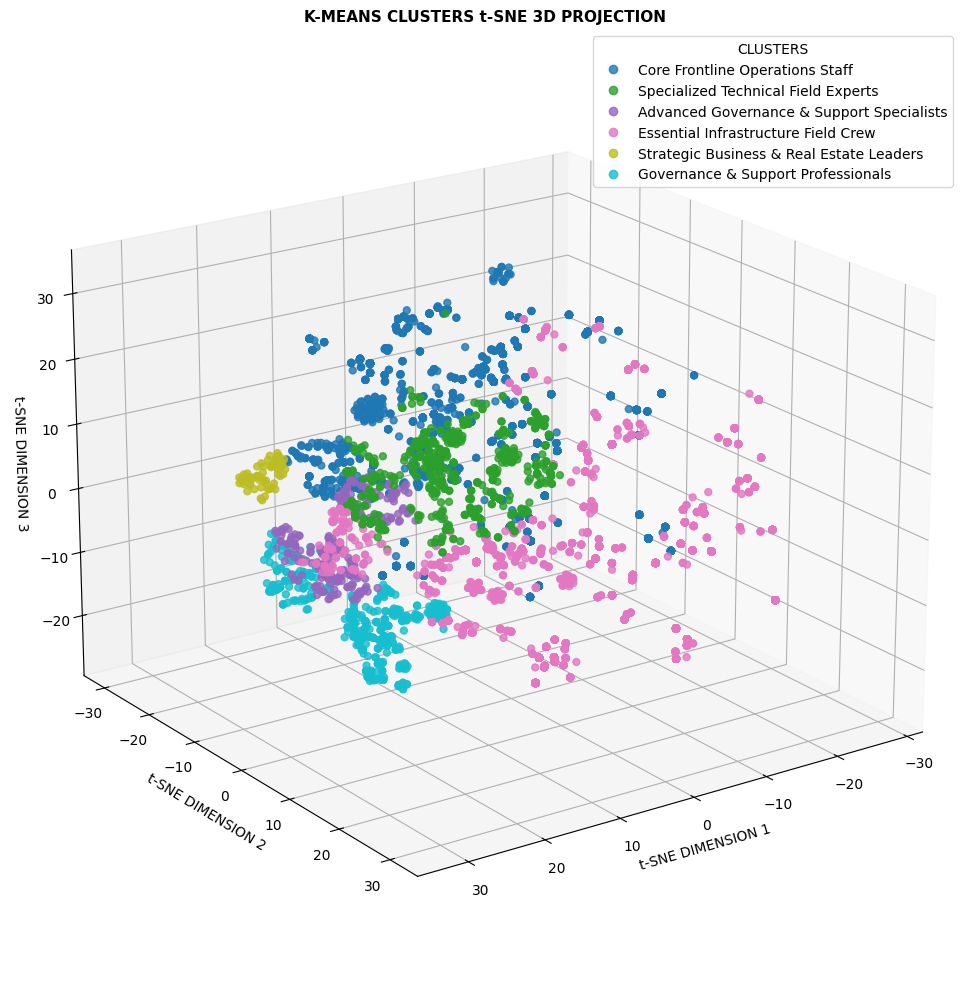

In [ ]:
# UMAP t-SNE COMPONENTS 3D SCATTER PLOT
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')
sc = ax.scatter(xs=dftsne3['TSNE1'], ys=dftsne3['TSNE2'], zs=dftsne3['TSNE3'], c=dftsne3['CLUSTER'], cmap='tab10', s=25, alpha=0.8)
ax.set_title('K-MEANS CLUSTERS t-SNE 3D PROJECTION', fontsize=11, fontweight='bold')
ax.set_xlabel('t-SNE DIMENSION 1')
ax.set_ylabel('t-SNE DIMENSION 2')
ax.set_zlabel('t-SNE DIMENSION 3')
ax.view_init(elev=20, azim=55)
handles, _ = sc.legend_elements()
legend_labels = [clabels[i] for i in range(len(handles))]
ax.legend(handles, legend_labels, title='CLUSTERS', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show();

RETIREMENT DYNAMICS: 
* Temporal dynamics - cluster-level retirement risk and workforce sustainability analysis

In [ ]:
# DATASET LOAD
c=['ID', 'DOB', 'RETIREMENTYEAR', 'YEARS2RETIREMENT', 'RETIREGROUP', 'GENERAL', 'TECHNICAL', 'DIGITAL', 'TOTALTRAINING']
path='SRT2026.csv'
df1 = pd.read_csv(path, usecols=c)
print(df1.info())
print(df1.isnull().sum())
df1.head()

<class 'pandas.DataFrame'>
RangeIndex: 8273 entries, 0 to 8272
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                8273 non-null   str    
 1   DOB               8273 non-null   str    
 2   GENERAL           8273 non-null   int64  
 3   TECHNICAL         8273 non-null   int64  
 4   DIGITAL           8273 non-null   int64  
 5   TOTALTRAINING     8273 non-null   int64  
 6   RETIREMENTYEAR    8273 non-null   int64  
 7   RETIREGROUP       8273 non-null   str    
 8   YEARS2RETIREMENT  8273 non-null   float64
dtypes: float64(1), int64(5), str(3)
memory usage: 581.8 KB
None
ID                  0
DOB                 0
GENERAL             0
TECHNICAL           0
DIGITAL             0
TOTALTRAINING       0
RETIREMENTYEAR      0
RETIREGROUP         0
YEARS2RETIREMENT    0
dtype: int64


,ID,DOB,GENERAL,TECHNICAL,DIGITAL,TOTALTRAINING,RETIREMENTYEAR,RETIREGROUP,YEARS2RETIREMENT
0,SRT_1,1971-09-08,1,0,0,1,2031,A (JAN-SEP),5.75
1,SRT_2,1965-10-11,1,0,0,1,2026,B (OCT-DEC),0.75
2,SRT_3,1970-08-18,0,0,0,0,2030,A (JAN-SEP),4.75
3,SRT_4,1967-07-02,0,0,0,0,2027,A (JAN-SEP),1.75
4,SRT_5,1969-06-19,0,0,0,0,2029,A (JAN-SEP),3.75


In [28]:
# REPREP DATA
data = df.copy()
data['DOB'] = pd.to_datetime(data['DOB'], format='%d/%m/%Y', errors='coerce')
data.drop(['DEPARTMENT', 'COURSE', 'PILLAR'], axis=1, inplace=True)
data = (
    data.groupby('ID', sort=False, as_index=False)
        .agg({
            'LEVEL': 'first',
            'TYPE': 'first',
            'GENERAL': 'sum',
            'TECHNICAL': 'sum',
            'DIGITAL': 'sum'
        })
)
data['TOTALTRAINING'] = data[['GENERAL', 'TECHNICAL', 'DIGITAL']].sum(axis=1)
data

,ID,LEVEL,TYPE,GENERAL,TECHNICAL,DIGITAL,TOTALTRAINING
0,SRT_1,14,Governance & Support,1,0,0,1
1,SRT_2,14,Governance & Support,1,0,0,1
2,SRT_3,14,Governance & Support,0,0,0,0
3,SRT_4,14,Governance & Support,0,0,0,0
4,SRT_5,14,Governance & Support,0,0,0,0
...,...,...,...,...,...,...,...
8268,SRT_8269,8,Governance & Support,5,0,0,5
8269,SRT_8270,8,Governance & Support,3,1,0,4
8270,SRT_8271,8,Governance & Support,12,2,1,15
8271,SRT_8272,6,Governance & Support,3,2,3,8


In [29]:
# ATTACH CLUSTERS BACK ONTO DATA
data['CLUSTERNUM'] = km6.labels_
data['CLUSTER'] = data['CLUSTERNUM'].map(clabels)
print(f'VALIDATION: {data.groupby('ID')['CLUSTER'].nunique().max()}')
# 1 → OK (VALIDATE CLUSTER CONSISTENCY)
data.head()

VALIDATION: 1


,ID,LEVEL,TYPE,GENERAL,TECHNICAL,DIGITAL,TOTALTRAINING,CLUSTERNUM,CLUSTER
0,SRT_1,14,Governance & Support,1,0,0,1,5,Governance & Support Professionals
1,SRT_2,14,Governance & Support,1,0,0,1,5,Governance & Support Professionals
2,SRT_3,14,Governance & Support,0,0,0,0,5,Governance & Support Professionals
3,SRT_4,14,Governance & Support,0,0,0,0,5,Governance & Support Professionals
4,SRT_5,14,Governance & Support,0,0,0,0,5,Governance & Support Professionals


In [30]:
# MERGE DF1 WITH THE CLUSTER LABELS
dfc = (data.groupby('ID')['CLUSTER'].first().reset_index())
dfm = df1.merge(dfc, on='ID', how='left')
dfm.head()

,ID,DOB,GENERAL,TECHNICAL,DIGITAL,TOTALTRAINING,RETIREMENTYEAR,RETIREGROUP,YEARS2RETIREMENT,CLUSTER
0,SRT_1,1971-09-08,1,0,0,1,2031,A (JAN-SEP),5.75,Governance & Support Professionals
1,SRT_2,1965-10-11,1,0,0,1,2026,B (OCT-DEC),0.75,Governance & Support Professionals
2,SRT_3,1970-08-18,0,0,0,0,2030,A (JAN-SEP),4.75,Governance & Support Professionals
3,SRT_4,1967-07-02,0,0,0,0,2027,A (JAN-SEP),1.75,Governance & Support Professionals
4,SRT_5,1969-06-19,0,0,0,0,2029,A (JAN-SEP),3.75,Governance & Support Professionals


In [31]:
# QUICK VALIDATION 1
assert dfm['CLUSTER'].isna().sum() == 0
assert dfm['ID'].nunique() == len(dfm)
print(f'NUMBER OF DUPLICATED ROWS: {dfm.duplicated().sum()}')
print(f'EXACT ONE ROW PER ID CHECK (BOOLEAN): {dfm['ID'].is_unique}')
dfm['CLUSTER'].value_counts()

NUMBER OF DUPLICATED ROWS: 0
EXACT ONE ROW PER ID CHECK (BOOLEAN): True


CLUSTER
Essential Infrastructure Field Crew          3856
Core Frontline Operations Staff              3127
Specialized Technical Field Experts           560
Governance & Support Professionals            428
Advanced Governance & Support Specialists     237
Strategic Business & Real Estate Leaders       65
Name: count, dtype: int64

In [32]:
# VALIDATION 2
print(dfm['CLUSTER'].value_counts())
pd.crosstab(data['CLUSTERNUM'], data['TYPE'])

CLUSTER
Essential Infrastructure Field Crew          3856
Core Frontline Operations Staff              3127
Specialized Technical Field Experts           560
Governance & Support Professionals            428
Advanced Governance & Support Specialists     237
Strategic Business & Real Estate Leaders       65
Name: count, dtype: int64


TYPE,Governance & Support,Infrastructure & Rolling Stock,Operations,Strategic Business & Real Estate
CLUSTERNUM,,,,
0,0,0,3127,0
1,0,519,41,0
2,151,33,53,0
3,0,3856,0,0
4,0,0,0,65
5,428,0,0,0


In [33]:
# VALIDATION 3
print(data.groupby('CLUSTERNUM')[['LEVEL', 'GENERAL', 'TECHNICAL', 'DIGITAL', 'TOTALTRAINING']].mean().round(2))
print()
print(pd.crosstab(data['CLUSTERNUM'], data['TYPE']))

            LEVEL  GENERAL  TECHNICAL  DIGITAL  TOTALTRAINING
CLUSTERNUM                                                   
0            4.60     0.21       0.83     0.05           1.09
1            6.65     1.06       5.59     0.23           6.88
2            7.59     8.11       1.83     2.76          12.70
3            5.37     0.13       0.77     0.03           0.93
4            7.97     4.94       2.49     1.29           8.72
5            7.11     1.97       0.98     0.41           3.36

TYPE        Governance & Support  Infrastructure & Rolling Stock  Operations  \
CLUSTERNUM                                                                     
0                              0                               0        3127   
1                              0                             519          41   
2                            151                              33          53   
3                              0                            3856           0   
4                      

In [34]:
# RETIREMENT RISK BANDS
def rb(y):
    if y <= 5:
        return 'CRITICAL'
    elif y <= 10:
        return 'MEDIUM'
    else:
        return 'LONG'

dfm['RISK'] = dfm['YEARS2RETIREMENT'].apply(rb)
riskorder = ['CRITICAL', 'MEDIUM', 'LONG']
dfm['RISK'] = pd.Categorical(dfm['RISK'], categories=riskorder, ordered=True)
dfm['RISK'].head()

0      MEDIUM
1    CRITICAL
2    CRITICAL
3    CRITICAL
4    CRITICAL
Name: RISK, dtype: category
Categories (3, str): ['CRITICAL' < 'MEDIUM' < 'LONG']

CLSUTER x RISK MATRIX - INTERPRETATION
* CRITICAL → immediate attrition risk
* MEDIUM → incoming retirement wave
* LONG → structurally stable cluster

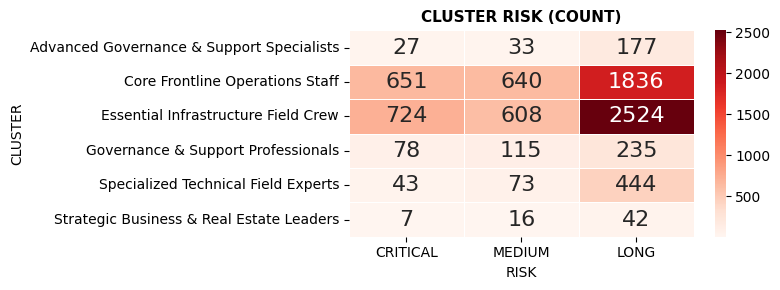

In [ ]:
# 1. CLUSTER X RISK MATRIX (COUNTS)
crc = pd.crosstab(dfm['CLUSTER'], dfm['RISK'])
plt.figure(figsize=(8, 3))
sns.heatmap(crc, annot=True, cmap='Reds', fmt='g', linewidths=0.5, annot_kws={'size': 16})
plt.title('CLUSTER RISK (COUNT)', fontsize=11, fontweight='bold')
plt.xlabel('RISK')
plt.ylabel('CLUSTER')
plt.tight_layout()
plt.savefig('F5.png', dpi=600, bbox_inches='tight')
plt.show();

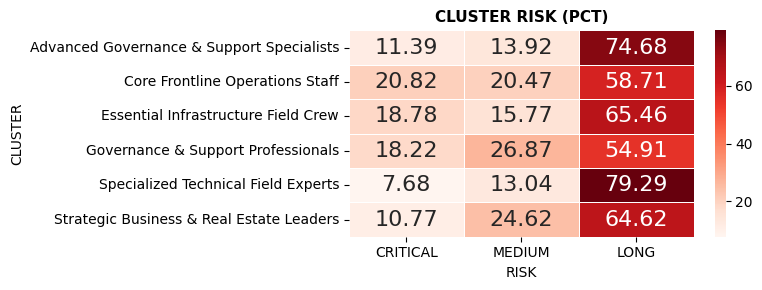

In [ ]:
# 2. CLUSTER X RISK MATRIX (PCT)
crp = pd.crosstab(dfm['CLUSTER'], dfm['RISK'], normalize='index') * 100
plt.figure(figsize=(8, 3))
sns.heatmap(crp, annot=True, cmap='Reds', fmt='.2f', linewidths=0.5, annot_kws={'size': 16})
plt.title('CLUSTER RISK (PCT)', fontsize=11, fontweight='bold')
plt.xlabel('RISK')
plt.ylabel('CLUSTER')
plt.tight_layout()
plt.show();

In [ ]:
# 3. RETIREMENT TIMELINE PER CLUSTER
pd.crosstab(dfm['RETIREMENTYEAR'], dfm['CLUSTER'])

CLUSTER,Advanced Governance & Support Specialists,Core Frontline Operations Staff,Essential Infrastructure Field Crew,Governance & Support Professionals,Specialized Technical Field Experts,Strategic Business & Real Estate Leaders
RETIREMENTYEAR,,,,,,
2025,0,0,8,1,0,0
2026,4,102,196,25,10,2
2027,4,145,131,13,9,1
2028,3,127,139,14,10,0
2029,12,146,142,11,10,3
2030,4,131,108,14,4,1
2031,4,133,124,30,12,2
2032,5,137,91,20,11,1
2033,3,111,116,14,20,3


In [ ]:
# 4. CAPABILITY WEIGHT LOSS
dfm.groupby(['RETIREMENTYEAR', 'CLUSTER'])['TOTALTRAINING'].sum().unstack(fill_value=0)

CLUSTER,Advanced Governance & Support Specialists,Core Frontline Operations Staff,Essential Infrastructure Field Crew,Governance & Support Professionals,Specialized Technical Field Experts,Strategic Business & Real Estate Leaders
RETIREMENTYEAR,,,,,,
2025,0,0,3,0,0,0
2026,41,71,106,59,61,9
2027,56,84,75,30,49,1
2028,60,77,97,24,47,0
2029,144,118,106,24,54,5
2030,58,81,96,36,26,12
2031,54,90,105,82,77,2
2032,56,123,72,52,65,15
2033,37,109,95,42,128,35


In [ ]:
# 5. RETIREMENT VELOCITY PER CLUSTER
clusteryear = pd.crosstab(dfm['RETIREMENTYEAR'], dfm['CLUSTER'])
velocity = clusteryear.diff().fillna(0)
clustersize = dfm['CLUSTER'].value_counts()
(velocity / clustersize).round(4)

CLUSTER,Advanced Governance & Support Specialists,Core Frontline Operations Staff,Essential Infrastructure Field Crew,Governance & Support Professionals,Specialized Technical Field Experts,Strategic Business & Real Estate Leaders
RETIREMENTYEAR,,,,,,
2025,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2026,0.0169,0.0326,0.0488,0.0561,0.0179,0.0308
2027,0.0000,0.0138,-0.0169,-0.0280,-0.0018,-0.0154
2028,-0.0042,-0.0058,0.0021,0.0023,0.0018,-0.0154
2029,0.0380,0.0061,0.0008,-0.0070,0.0000,0.0462
2030,-0.0338,-0.0048,-0.0088,0.0070,-0.0107,-0.0308
2031,0.0000,0.0006,0.0041,0.0374,0.0143,0.0154
2032,0.0042,0.0013,-0.0086,-0.0234,-0.0018,-0.0154
2033,-0.0084,-0.0083,0.0065,-0.0140,0.0161,0.0308


In [51]:
# 6. FISCAL POLICY SPLIT (GROUP A VS B) NORMALISED
(pd.crosstab(dfm['CLUSTER'], dfm['RETIREGROUP'], normalize='index') * 100).round(2)

RETIREGROUP,A (JAN-SEP),B (OCT-DEC)
CLUSTER,,
Advanced Governance & Support Specialists,68.35,31.65
Core Frontline Operations Staff,75.12,24.88
Essential Infrastructure Field Crew,72.87,27.13
Governance & Support Professionals,72.90,27.10
Specialized Technical Field Experts,75.54,24.46
Strategic Business & Real Estate Leaders,73.85,26.15


In [52]:
# 7. NEAR TERM CAPABILITY RISK (0-5 YEARS)
nearterm = dfm[dfm['YEARS2RETIREMENT'] <= 5]
crisk5y = (nearterm.groupby('CLUSTER')['TOTALTRAINING'].sum()/ dfm.groupby('CLUSTER')['TOTALTRAINING'].sum()) * 100
pd.DataFrame(crisk5y).round(2)

,TOTALTRAINING
CLUSTER,
Advanced Governance & Support Specialists,11.93
Core Frontline Operations Staff,12.63
Essential Infrastructure Field Crew,13.47
Governance & Support Professionals,12.03
Specialized Technical Field Experts,6.16
Strategic Business & Real Estate Leaders,4.76


In [53]:
# 8. COMPOSITE RISK INDEX - RANK VLUNERABILITY OF CLUSTERS
crpct = pd.crosstab(dfm['CLUSTER'], dfm['RISK'], normalize='index') * 100
c1 = crpct['CRITICAL'] / 100 # Percentage of people retiring in ≤5 years
c2 = crisk5y / 100 # Percentage of capability retiring in ≤5 years
(0.5 * c1 + 0.5 * c2).sort_values(ascending=False).round(4)

CLUSTER
Core Frontline Operations Staff              0.1672
Essential Infrastructure Field Crew          0.1612
Governance & Support Professionals           0.1513
Advanced Governance & Support Specialists    0.1166
Strategic Business & Real Estate Leaders     0.0777
Specialized Technical Field Experts          0.0692
dtype: float64

In [54]:
# 9. RISK COVERAGE
dfm['RISK'].value_counts()

RISK
LONG        5258
CRITICAL    1530
MEDIUM      1485
Name: count, dtype: int64

In [ ]:
# 10. YEARS2RETIREMENT CONSISTENCY CHECK
dfm.groupby('CLUSTER')['YEARS2RETIREMENT'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
CLUSTER,,,,,,,,
Advanced Governance & Support Specialists,237.0,18.08,9.72,0.75,9.75,16.75,26.75,35.75
Core Frontline Operations Staff,3127.0,14.49,9.60,0.75,5.75,12.75,22.75,36.75
Essential Infrastructure Field Crew,3856.0,14.83,9.46,-0.25,7.75,13.75,21.75,38.75
Governance & Support Professionals,428.0,13.97,9.66,-0.25,5.75,11.75,20.75,36.75
Specialized Technical Field Experts,560.0,19.51,10.07,0.75,11.50,18.75,28.75,38.75
Strategic Business & Real Estate Leaders,65.0,17.43,10.11,0.75,8.75,16.75,26.75,34.75


In [56]:
# 11. CAPABILITY DISTRIBUTION
dfm.groupby('CLUSTER')['TOTALTRAINING'].describe()

,count,mean,std,min,25%,50%,75%,max
CLUSTER,,,,,,,,
Advanced Governance & Support Specialists,237.0,12.696203,4.535232,5.0,9.0,12.0,15.0,36.0
Core Frontline Operations Staff,3127.0,1.091461,1.309428,0.0,0.0,1.0,2.0,8.0
Essential Infrastructure Field Crew,3856.0,0.929720,1.101108,0.0,0.0,1.0,2.0,6.0
Governance & Support Professionals,428.0,3.359813,2.657934,0.0,1.0,3.0,5.0,10.0
Specialized Technical Field Experts,560.0,6.875000,3.276536,3.0,5.0,6.0,8.0,24.0
Strategic Business & Real Estate Leaders,65.0,8.723077,5.641663,0.0,4.0,9.0,13.0,27.0


In [57]:
# QUICK VALIDATION
assert dfm['CLUSTER'].isna().sum() == 0
assert dfm['ID'].nunique() == len(dfm)
print(f'NUMBER OF DUPLICATED ROWS: {dfm.duplicated().sum()}')
print(f'EXACT ONE ROW PER ID CHECK (BOOLEAN): {dfm['ID'].is_unique}')
dfm['CLUSTER'].value_counts()

NUMBER OF DUPLICATED ROWS: 0
EXACT ONE ROW PER ID CHECK (BOOLEAN): True


CLUSTER
Essential Infrastructure Field Crew          3856
Core Frontline Operations Staff              3127
Specialized Technical Field Experts           560
Governance & Support Professionals            428
Advanced Governance & Support Specialists     237
Strategic Business & Real Estate Leaders       65
Name: count, dtype: int64

___
**END**